pip install stable-baselines3[extra] gymnasium[atari]


In [ ]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
import numpy as np
import matplotlib.pyplot as plt

# 1. 创建多个并行环境
num_envs = 4
env = SubprocVecEnv([lambda: gym.make("CartPole-v1") for _ in range(num_envs)])

# 2. 初始化 PPO 模型（优化超参数）
model = PPO(
    "MlpPolicy",
    env,
    learning_rate=0.0003, 
    gamma=0.99, 
    ent_coef=0.01,  # 正确方式 增加探索
    clip_range=0.2,      # 让训练更稳定
    verbose=0,
)

# 3. 训练模型（训练更久）
model.learn(total_timesteps=500_000)


# 4. 保存模型
model.save("./data/ppo_cartpole")

Using cuda device
-----------------------------
| time/              |      |
|    fps             | 2197 |
|    iterations      | 1    |
|    time_elapsed    | 3    |
|    total_timesteps | 8192 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1346        |
|    iterations           | 2           |
|    time_elapsed         | 12          |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.014543939 |
|    clip_fraction        | 0.213       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.681      |
|    explained_variance   | -0.000103   |
|    learning_rate        | 0.0003      |
|    loss                 | 2.63        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0241     |
|    value_loss           | 18.1        |
-----------------------------------------
----------------

c:\Users\崔崟\anaconda3\envs\py_gpu_new\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


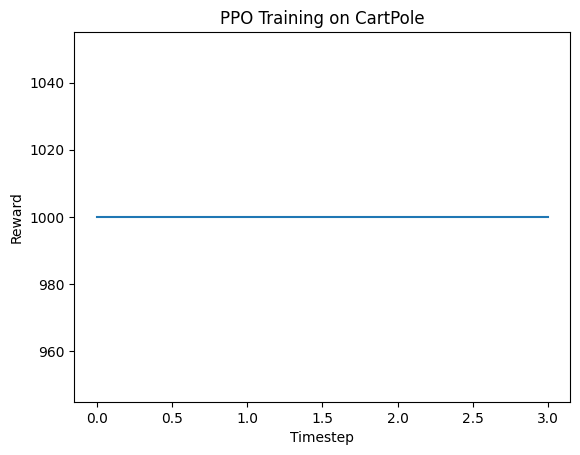

In [30]:
import numpy as np

# 5. 载入模型
model = PPO.load("./data/ppo_cartpole")

# 6. 评估训练好的模型
obs = env.reset()
rewards = np.zeros(num_envs)  # 记录每个环境的奖励
for _ in range(1000):  # 运行1000步
    action, _ = model.predict(obs)
    obs, reward, done, info = env.step(action)
    # print(f"obs: {obs.shape}, reward: {reward.shape}, done: {done.shape}, info: {type(info)}")

    rewards += reward  # 累积奖励
    # env.render()  # 可视化

    # # debug: print done and its type
    # print(done, type(done))

    # 逐个重置已完成的环境
    # 只重置完成的环境
    for i in range(num_envs):
        if done[i]:
            obs[i] = env.reset()[i]

# env.close()

# 7. 绘制奖励变化
plt.plot(rewards)
plt.xlabel("Timestep")
plt.ylabel("Reward")
plt.title("PPO Training on CartPole")
plt.show()
